# Connect to Drive

## 📂 Image Dataset Overview

**Total Images:** 25,643  

### 🏷 Class Distribution:
- **Biodegradable:** 8,363  
- **Recyclable:** 8,336  
- **Non-Recyclable:** 8,944  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q "/content/drive/MyDrive/HackathonDataset/Dataset.zip" -d "/content/dataset"

In [ ]:
# !pip install tensorflow opencv-python numpy pandas matplotlib scikit-learn pillow tf2onnx

# Import Libraries

In [ ]:
# Import Libraries
import tensorflow as tf
import tf2onnx
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Data Preprocessing

In [ ]:
# Set Paths (Change this to correct path If required)
TRAIN_PATH = "/content/dataset/Dataset/train"
TEST_PATH = "/content/dataset/Dataset/test"
VAL_PATH = "/content/dataset/Dataset/val"

In [ ]:
# Image Data Generators for Augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)  # No augmentation for validation & test

In [ ]:
# Load Train Data
train_data = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["recyclable", "non_recyclable", "biodegradable"]  # Force correct order
)

# Load Validation Data
val_data = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["recyclable", "non_recyclable", "biodegradable"]  # Force correct order
)

# Load Test Data
test_data = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=["recyclable", "non_recyclable", "biodegradable"],  # Force correct order
    shuffle=False  # Keep order for evaluation
)

Found 20513 images belonging to 3 classes.
Found 2563 images belonging to 3 classes.
Found 2567 images belonging to 3 classes.


# AI Model

In [ ]:
# Define AI Model (Transfer Learning with MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Unfreeze last few layers of MobileNetV2 (Fine-tuning Step)
for layer in base_model.layers[-20:]:  # Unfreeze last 20 layers
    layer.trainable = True

# Create Model (Adding Custom Layers)
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation="softmax")(x)  # 3 Classes: Recyclable, Non-Recyclable, Biodegradable

In [ ]:
# Compile Model
model = Model(inputs=base_model.input, outputs=output_layer)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
# Define Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6)

# Train Ai Model


In [ ]:
# Train the Model
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 352s 450ms/step - accuracy: 0.6219 - loss: 0.8049 - val_accuracy: 0.9345 - val_loss: 0.2088 - learning_rate: 1.0000e-05
Epoch 2/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 271s 421ms/step - accuracy: 0.9089 - loss: 0.2570 - val_accuracy: 0.9633 - val_loss: 0.1157 - learning_rate: 1.0000e-05
Epoch 3/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 265s 412ms/step - accuracy: 0.9446 - loss: 0.1644 - val_accuracy: 0.9711 - val_loss: 0.0785 - learning_rate: 1.0000e-05
Epoch 4/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 325s 417ms/step - accuracy: 0.9524 - loss: 0.1361 - val_accuracy: 0.9758 - val_loss: 0.0671 - learning_rate: 1.0000e-05
Epoch 5/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 264s 412ms/step - accuracy: 0.9566 - loss: 0.1232 - val_accuracy: 0.9785 - val_loss: 0.0614 - learning_rate: 1.0000e-05
Epoch 6/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 324s 414ms/step - accuracy: 0.9640 - loss: 0.1060 - val_accuracy: 0.9778 - val_loss: 0.0634 - learning_rate: 1.0000e-05
Epoch 7/30
642/642 ━━━━━━━━━━━━━━━━━━━━ 

# Save Ai Model

In [ ]:
# h5 Model (.h5) Old version
model.save("waste_classifier.h5")

In [ ]:
# Keras Format (.keras)
model.save("waste_classifier.keras")

In [ ]:
# TensorFlow SavedModel (.pb format) for FastAPI
tf.saved_model.save(model, "waste_classifier_savedmodel")

In [ ]:
# ONNX for Cross-Platform Use

# Load the model
saved_model_dir = "waste_classifier_savedmodel"
model = tf.saved_model.load(saved_model_dir)

# Convert to ONNX
onnx_model, _ = tf2onnx.convert.from_saved_model(saved_model_dir, opset=13)

# Save ONNX model
onnx_model_path = "waste_classifier.onnx"
with open(onnx_model_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"ONNX model saved at {onnx_model_path}")

In [ ]:
# TensorFlow Lite (.tflite) for Mobile/Edge Deployment
converter = tf.lite.TFLiteConverter.from_saved_model("waste_classifier_savedmodel")
tflite_model = converter.convert()
with open("waste_classifier.tflite", "wb") as f:
    f.write(tflite_model)

# Ai Model Evaluation

In [ ]:
# Model Evaluation on Test Data
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Accuracy: {test_acc:.4f}")

81/81 ━━━━━━━━━━━━━━━━━━━━ 8s 100ms/step - accuracy: 0.9845 - loss: 0.0477
Test Accuracy: 0.9832


In [ ]:
# Generate Classification Report
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes

print("Classification Report:\n", classification_report(y_true, y_pred_classes, target_names=test_data.class_indices.keys()))

81/81 ━━━━━━━━━━━━━━━━━━━━ 19s 154ms/step
Classification Report:
                 precision    recall  f1-score   support

 biodegradable       1.00      0.99      0.99       837
non_recyclable       0.96      0.98      0.97       895
    recyclable       0.97      0.95      0.96       835

      accuracy                           0.97      2567
     macro avg       0.98      0.97      0.97      2567
  weighted avg       0.97      0.97      0.97      2567



In [ ]:
print(train_data.class_indices)

{'recyclable': 0, 'non_recyclable': 1, 'biodegradable': 2}


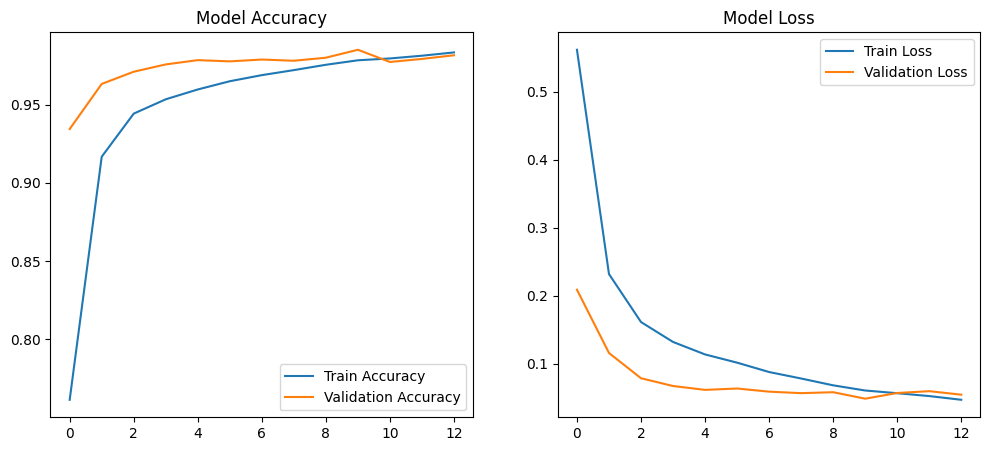

In [ ]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.legend()
plt.title("Model Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Model Loss")

plt.show()

# Testing Final Ai Model

In [ ]:
# Load Trained Model
model = tf.keras.models.load_model("/content/drive/MyDrive/HackathonDataset/waste_classifier.keras")

/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 164 variables whereas the saved optimizer has 326 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
# Define Class Labels (Same as Dataset Folder Names)
CLASS_NAMES = ["Recyclable", "Non-Recyclable", "Biodegradable"]

In [ ]:
# Function to Predict Waste Category
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))  # Resize
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)
    confidence = np.max(prediction)

    print(f"Prediction: {CLASS_NAMES[class_index]} (Confidence: {confidence:.2f})")

In [ ]:
# Test with a Sample Image
predict_image("/content/drive/MyDrive/HackathonDataset/test/biodegradable/biological589.jpg")  # Change this to an actual image path

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Prediction: Biodegradable (Confidence: 0.91)


# Copying Ai Model to Drive

In [ ]:
!cp /content/waste_classifier.keras /content/drive/MyDrive/HackathonDataset

In [ ]:
!cp /content/waste_classifier.h5 /content/drive/MyDrive/HackathonDataset